In [170]:
import torch
print(torch.cuda.is_available())

False


In [171]:
words = open('names.txt', 'r').read().splitlines()

In [172]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [173]:
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))

32033
2
15


## Building a Bigram

In [174]:
b = {} # this is a dictionary, we're just counting how much each bigram combination appears 
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)
        

In [175]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [176]:
sorted(b.items(), key = lambda kv: -kv[1]) # sorting by most likely bigrams

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [177]:
import torch

In [178]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [179]:
# len(set(''.join(words)))

# So here we're just creating a look up table
# that will map each character to a specific index
# we need this integer representation so that we can translate
# the characters into a tensor index (i think!)
chars = sorted(list(set(''.join(words))))
print("chars", chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
# stoi['<S>'] = 26
# stoi['<E>'] = 27
stoi['.'] = 0

print(stoi)

chars ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [191]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1
    
print(N)

tensor([[    0,  8820,  2612,  3084,  3380,  3062,   834,  1338,  1748,  1182,
          4844,  5926,  3144,  5076,  2292,   788,  1030,   184,  3278,  4110,
          2616,   156,   752,   614,   268,  1070,  1858],
        [13280,  1112,  1082,   940,  2084,  1384,   268,   336,  4664,  3300,
           350,  1136,  5056,  3268, 10876,   126,   164,   120,  6528,  2236,
          1374,   762,  1668,   322,   364,  4100,   870],
        [  228,   642,    76,     2,   130,  1310,     0,     0,    82,   434,
             2,     0,   206,     0,     8,   210,     0,     0,  1684,    16,
             4,    90,     0,     0,     0,   166,     0],
        [  194,  1630,     0,    84,     2,  1102,     0,     4,  1328,   542,
             6,   632,   232,     0,     0,   760,     2,    22,   152,    10,
            70,    70,     0,     0,     6,   208,     8],
        [ 1032,  2606,     2,     6,   298,  2566,    10,    50,   236,  1348,
            18,     6,   120,    60,    62,   756,   

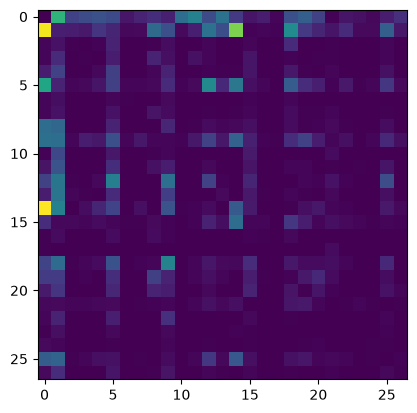

In [192]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

In [193]:
itos = {i:s for s,i  in stoi.items()} # inversing the loopup math
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

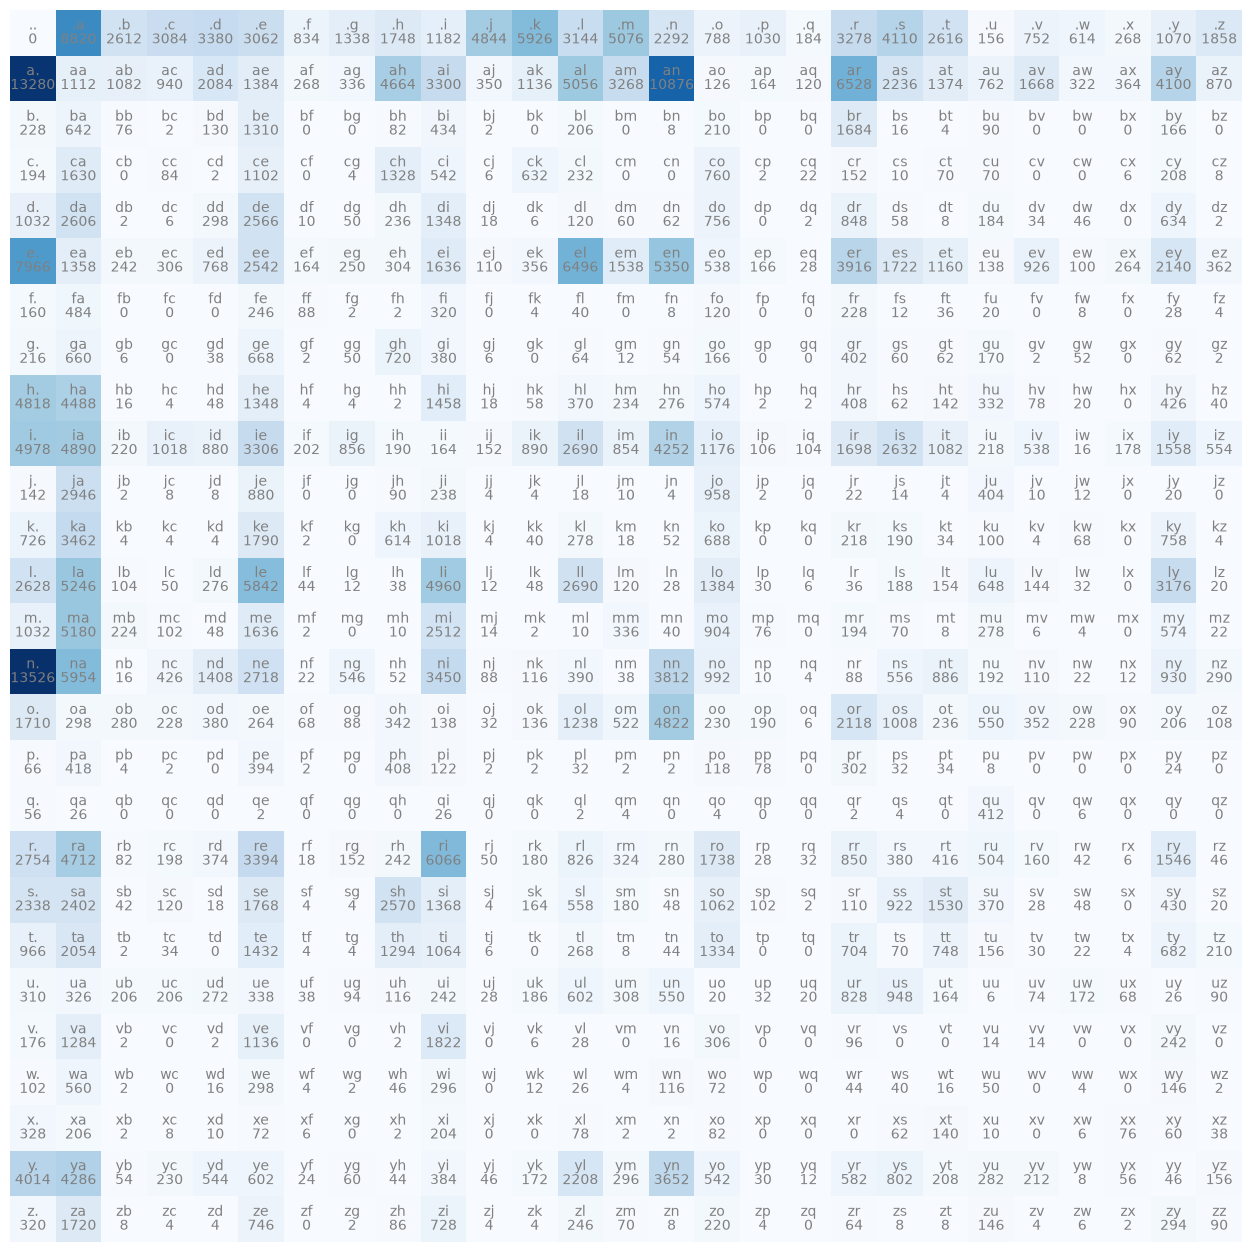

In [194]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

# i typed something wrong around here but i don't really think this is important enough for me to fix
# so i'm just gonna move on for now
# okay so making the changes to remove <S> and <E> fixes it? maybe i just didn't run something in the correct order
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')

plt.axis('off')

In [195]:
N[0, :].shape

torch.Size([27])

In [196]:
# this apparently gives you the probabality of each character being the first character in a word
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [197]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
print("raw (unormalized)", p)

p = p / p.sum()
print("normalized", p)

raw (unormalized) tensor([0.7081, 0.3542, 0.1054])
normalized tensor([0.6064, 0.3033, 0.0903])


In [198]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [199]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

itos[ix]

'.'

In [200]:
g = torch.Generator().manual_seed(2147483647)
for i in range(50):

    output = []
    ix = 0

    while True:
        p = N[ix].float()
        p = p / p.sum()
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        
        # print(itos[ix])
        output.append(itos[ix])
        
        if (ix == 0):
            break

    print(''.join(output))
    

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.
x.
al.
kal.
thavazeeromysos.
laitenimieegariseriyen.
k.
illeleldole.
meenisammigama.
mmin.
asharin.
alcalar.
jayn.
asaz.
selanely.
chay.
rana.
ai.
yviamisashougen.
l.
beyncaro.
allan.
annutetoradrilia.
rddeman.


In [201]:
P = N.float()
P = P / P.sum(1, keepdim=True)

print(P[0].sum())

tensor(1.)


In [228]:
# this is just printing out the probabalities 
# of each biagram based on the total population 
# within the tensor matrix of frequency probabalities (I think, no clue)
# if any of this is correct terminolyg
xs, ys = [], []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        xs.append(ix1)
        ys.append(ix2)
        
        print(f'{ch1}{ch2}: {prob:.4f}')
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960


In [229]:
xs

tensor([ 0,  5, 13, 13,  1])

In [230]:
import torch.nn.functional as F

# xs is a array so the ouptut here is mulitple one hot encodings
xenc = F.one_hot(xs, num_classes=27).float() # https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.one_hot.html
print(xenc)
print(xenc.dtype)


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])
torch.float32


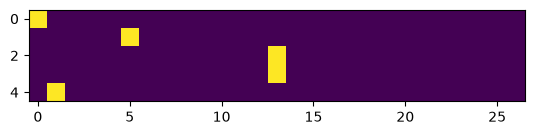

In [231]:
xenc.shape
plt.imshow(xenc)

In [236]:
# initializing random weights 
import torch
W = torch.randn((27, 27))
output = xenc @ W
print(xenc.shape)
print(W.shape)
print(output.shape)
print(output)

torch.Size([5, 27])
torch.Size([27, 27])
torch.Size([5, 27])
tensor([[ 3.6173e-01, -6.3582e-01, -1.6348e+00, -1.2634e-01, -3.5124e-01,
          1.0359e+00,  8.3458e-01,  1.7983e+00,  1.4266e+00, -1.0499e+00,
          4.8801e-01,  4.2078e-01,  5.0079e-01, -8.1108e-01, -1.6822e+00,
          1.7139e+00,  1.0790e+00,  8.5518e-01,  1.4311e-01,  1.1869e+00,
          9.6631e-01, -1.3661e-01, -2.6086e-01,  5.3734e-01, -2.0046e+00,
          4.1164e-01,  5.1359e-01],
        [ 5.4700e-01, -2.3793e-02,  6.4832e-01, -3.4418e-01, -2.0244e+00,
          1.0493e+00,  3.8972e-01, -1.9251e+00, -4.0918e-01,  1.8777e-01,
         -1.0463e+00, -1.0506e+00,  1.8438e+00, -5.1609e-01, -9.5239e-01,
         -4.3423e-01,  5.0607e-01, -4.3376e-01,  1.6887e+00, -9.6937e-02,
          4.4498e-02,  1.1510e+00, -3.6133e-02,  5.5052e-01,  1.1770e+00,
         -9.3131e-01,  2.2074e-01],
        [ 4.7659e-01,  5.1535e-01,  2.7470e-01, -1.1259e+00, -6.6188e-02,
         -6.4912e-01,  3.8854e-02, -9.5736e-01,  1.32

In [241]:
output = (xenc @ W)
print(output.shape) 
print(output[3, 13]) # just shorthand for the below
print(output[3][13])

# we can also just do something like
(xenc @ W)[3,13]

torch.Size([5, 27])
tensor(-0.5225)
tensor(-0.5225)


tensor(-0.5225)

In [242]:
# without dotnet product we're just doing
(xenc[3] * W[:, 13]).sum()

tensor(-0.5225)

In [247]:
logits = xenc @ W
counts = logits.exp() # log probabalities, apparently this is equivalent to the N matrix through somehow something
probs = counts / counts.sum(1, keepdims=True) # yh this is just softmax
probs

tensor([[0.0291, 0.0107, 0.0039, 0.0178, 0.0142, 0.0570, 0.0466, 0.1222, 0.0843,
         0.0071, 0.0330, 0.0308, 0.0334, 0.0090, 0.0038, 0.1123, 0.0595, 0.0476,
         0.0233, 0.0663, 0.0532, 0.0176, 0.0156, 0.0346, 0.0027, 0.0305, 0.0338],
        [0.0423, 0.0239, 0.0468, 0.0173, 0.0032, 0.0699, 0.0361, 0.0036, 0.0162,
         0.0295, 0.0086, 0.0086, 0.1546, 0.0146, 0.0094, 0.0158, 0.0406, 0.0159,
         0.1324, 0.0222, 0.0256, 0.0773, 0.0236, 0.0424, 0.0794, 0.0096, 0.0305],
        [0.0280, 0.0291, 0.0229, 0.0056, 0.0163, 0.0091, 0.0181, 0.0067, 0.0655,
         0.0158, 0.0218, 0.0033, 0.0126, 0.0103, 0.0243, 0.0248, 0.0129, 0.0094,
         0.0193, 0.0184, 0.0229, 0.0111, 0.0952, 0.4132, 0.0075, 0.0594, 0.0163],
        [0.0280, 0.0291, 0.0229, 0.0056, 0.0163, 0.0091, 0.0181, 0.0067, 0.0655,
         0.0158, 0.0218, 0.0033, 0.0126, 0.0103, 0.0243, 0.0248, 0.0129, 0.0094,
         0.0193, 0.0184, 0.0229, 0.0111, 0.0952, 0.4132, 0.0075, 0.0594, 0.0163],
        [0.0380, 0.0215,

In [250]:
probs[0].sum() 
probs[0] # i think this is supposed to be equivalent to the first row of the thing one hot encoding but i'm not sure, it doesn't seem to perfectly line up

tensor([0.0291, 0.0107, 0.0039, 0.0178, 0.0142, 0.0570, 0.0466, 0.1222, 0.0843,
        0.0071, 0.0330, 0.0308, 0.0334, 0.0090, 0.0038, 0.1123, 0.0595, 0.0476,
        0.0233, 0.0663, 0.0532, 0.0176, 0.0156, 0.0346, 0.0027, 0.0305, 0.0338])

In [253]:
nlls = torch.zeros(5)

for i in range(5):
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    
    print(x, y)
    
    print('----------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character)":', y)
    
    p = probs[i,y]
    
    print('probability assigned by the net to the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood', logp.item())
    
    nll = -logp

    print('negative log likelihood', nll.item())
    nlls[i] = nll
    
print('================')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())    
    

0 5
----------
bigram example 1: .e (indexes 0, 5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0291, 0.0107, 0.0039, 0.0178, 0.0142, 0.0570, 0.0466, 0.1222, 0.0843,
        0.0071, 0.0330, 0.0308, 0.0334, 0.0090, 0.0038, 0.1123, 0.0595, 0.0476,
        0.0233, 0.0663, 0.0532, 0.0176, 0.0156, 0.0346, 0.0027, 0.0305, 0.0338])
label (actual next character)": 5
probability assigned by the net to the correct character: 0.05700766295194626
log likelihood -2.864569664001465
negative log likelihood 2.864569664001465
5 13
----------
bigram example 2: em (indexes 5, 13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0423, 0.0239, 0.0468, 0.0173, 0.0032, 0.0699, 0.0361, 0.0036, 0.0162,
        0.0295, 0.0086, 0.0086, 0.1546, 0.0146, 0.0094, 0.0158, 0.0406, 0.0159,
        0.1324, 0.0222, 0.0256, 0.0773, 0.0236, 0.0424, 0.0794, 0.0096, 0.0305])
label (actual next character)": 13
probability assigned by the net to the correct charac

In [260]:
# print(xs)
print(ys) # labels

tensor([ 5, 13, 13,  1,  0])


In [254]:
probs[0,5], probs[1,13],probs[2,13],probs[3,1],probs[4,0]

(tensor(0.0570),
 tensor(0.0146),
 tensor(0.0103),
 tensor(0.0291),
 tensor(0.0380))

In [257]:
probs[torch.arange(5), ys]

tensor([0.0570, 0.0146, 0.0103, 0.0291, 0.0380])

In [261]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.6938)

In [263]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss = -probs[torch.arange(5), ys].log().mean()

In [264]:
# backward pass 
W.grad = None # set to zero the gradient
loss.backward()




In [ ]:
W.grad 